In [1]:
# !pip install langchain-opentutorial

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_teddynote import logging

logging.langsmith("CH15-Agentic-RAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH15-Agentic-RAG


# Agentic RAG

= NaiveRAG + RelevanceCheck + WebSearch + QueryRewrite

In [3]:
file_path = ["data/SPRi AI Brief_Special_AI Agent_241209_F.pdf"]

### Retrieval Chain

In [4]:
from langchain_opentutorial.rag.pdf import PDFRetrievalChain

In [5]:
pdf_file = PDFRetrievalChain(file_path).create_chain()

pdf_retriever = pdf_file.retriever
pdf_chain = pdf_file.chain

## Retrieval Tool 정의

In [6]:
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.prompts import PromptTemplate

In [7]:
# PDF 문서를 기반으로 검색 도구 생성
retriever_tool = create_retriever_tool(
    pdf_retriever,
    "pdf_retriever",
    "Search and return information about SPRI AI Brief PDF file. It contains useful information on recent AI Agent trends. The document is published on Dec 2024.",
    document_prompt=PromptTemplate.from_template(
        "<document><context>{page_content}</context><metadata><source>{source}</source><page>{page}</page></metadata></document>"
    ),
)

# 생성된 검색 도구를 도구 리스트에 추가하여 에이전트에서 사용 가능하도록 설정
tools = [retriever_tool]

### Agent 상태 정의

In [8]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [9]:
class AgentState(TypedDict):
    # add_messages reducer 함수를 사용하여 메시지 시퀀스를 관리
    messages: Annotated[Sequence[BaseMessage], add_messages]

### Node & Edge 정의

In [10]:
from typing import Literal
from langchain import hub
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import tools_condition
from langchain_teddynote.models import get_model_name, LLMs

In [11]:
# 최신 모델이름 가져오기
MODEL_NAME = get_model_name(LLMs.GPT4)

In [12]:
# 데이터 모델 정의
class grade(BaseModel):
    """A binary score for relevance checks"""
    binary_score: str = Field(
        description="Response 'yes' if the document is relevant to the question or 'no' if it is not."
    )


def grade_documents(state) -> Literal["generate", "rewrite"]:
    # LLM 모델 초기화
    model = ChatOpenAI(temperature=0, model=MODEL_NAME, streaming=True)

    # 구조화된 출력을 위한 LLM 설정
    llm_with_tool = model.with_structured_output(grade)

    # 프롬프트 템플릿 정의
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # llm + tool 바인딩 체인 생성
    chain = prompt | llm_with_tool

    # 현재 상태에서 메시지 추출
    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content

    # 검색된 문서 추출
    retrieved_docs = last_message.content

    # 관련성 평가 실행
    scored_result = chain.invoke({"question": question, "context": retrieved_docs})

    # 관련성 여부 추출
    score = scored_result.binary_score

    # 관련성 여부에 따른 결정
    if score == "yes":
        print("==== [DECISION: DOCS RELEVANT] ====")
        return "generate"

    else:
        print("==== [DECISION: DOCS NOT RELEVANT] ====")
        print(score)
        return "rewrite"


def agent(state):
    # 현재 상태에서 메시지 추출
    messages = state["messages"]

    # LLM 모델 초기화
    model = ChatOpenAI(temperature=0, streaming=True, model=MODEL_NAME)

    # retriever tool 바인딩
    model = model.bind_tools(tools)

    # 에이전트 응답 생성
    response = model.invoke(messages)

    # 기존 리스트에 추가되므로 리스트 형태로 반환
    return {"messages": [response]}


def rewrite(state):
    print("==== [QUERY REWRITE] ====")
    # 현재 상태에서 메시지 추출
    messages = state["messages"]
    # 원래 질문 추출
    question = messages[0].content

    # 질문 개선을 위한 프롬프트 구성
    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # LLM 모델로 질문 개선
    model = ChatOpenAI(temperature=0, model=MODEL_NAME, streaming=True)
    # Query-Transform 체인 실행
    response = model.invoke(msg)

    # 재작성된 질문 반환
    return {"messages": [response]}


def generate(state):
    # 현재 상태에서 메시지 추출
    messages = state["messages"]

    # 원래 질문 추출
    question = messages[0].content

    # 가장 마지막 메시지 추출
    docs = messages[-1].content

    # RAG 프롬프트 템플릿 가져오기
    prompt = hub.pull("teddynote/rag-prompt")

    # LLM 모델 초기화
    llm = ChatOpenAI(model_name=MODEL_NAME, temperature=0, streaming=True)

    # RAG 체인 구성
    rag_chain = prompt | llm | StrOutputParser()

    # 답변 생성 실행
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [13]:
# Web Search 노드
def web_search(state: GraphState) -> GraphState:
    tavily_tool = TavilySearch()
    
    # search_query = state["question"]
    search_query = state["question"][-1].content

    search_result = tavily_tool.search(
        query=search_query,  # 검색 쿼리
        topic="general",     # 일반 주제
        # days=1,
        max_results=3,       # 최대 검색 결과
        format_output=True,  # 결과 포맷팅
    )

    return GraphState(context="\n".join(search_result))

### 그래프 정의

In [13]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [14]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)        # 에이전트 노드
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)  # 검색 노드
workflow.add_node("rewrite", rewrite)    # 질문 재작성 노드
workflow.add_node("generate", generate)  # 관련 문서 확인 후 응답 생성 노드

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

graph = workflow.compile()

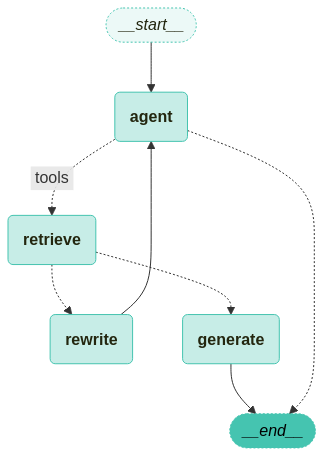

In [15]:
from langchain_teddynote.graphs import visualize_graph  

visualize_graph(graph)  

### 그래프 실행

In [16]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, random_uuid

In [ ]:
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

In [22]:
# 문서 검색 기반 질문
inputs = {
    "messages": [
        ("user", "구글이 진행하고 있는 Project Astra는 무엇?"),
    ]
}

# 그래프 실행
stream_graph(graph, inputs, config, ["agent", "rewrite", "generate"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [DECISION: DOCS RELEVANT] ====

🔄 Node: generate 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
구글의 Project Astra는 보편적인 AI 에이전트를 개발하는 프로젝트로, AI 기술을 활용하여 사용자 경험을 극대화하고 다양한 산업에 적용 가능한 AI 에이전트를 제공하는 것을 목표로 합니다. 이 프로젝트는 다중모드 정보를 처리하고 사용자의 상황을 이해하며 자연스러운 대화 응답을 가능하게 하는 AI 어시스턴트를 탐구합니다.

**Source**
- data/SPRi AI Brief_Special_AI Agent_241209_F.pdf (page 6)
- data/SPRi AI Brief_Special_AI Agent_241209_F.pdf (page 7)
- data/SPRi AI Brief_Special_AI Agent_241209_F.pdf (page 8)

In [ ]:
# 문서 검색이 안되는 질문 
inputs = {
    "messages": [
        ("user", "도널드 트럼프 대통령"),
    ]
}

stream_graph(graph, inputs, config, ["agent", "rewrite", "generate"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [DECISION: DOCS NOT RELEVANT] ====
no
==== [QUERY REWRITE] ====

🔄 Node: rewrite 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
What are the key policies and actions of President Donald Trump during his time in office?
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
==== [DECISION: DOCS NOT RELEVANT] ====
no
==== [QUERY REWRITE] ====

🔄 Node: rewrite 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
What are the key policies and actions of President Donald Trump during his time in office?
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
During his presidency, Donald Trump implemented a range of key policies and actions across various domains. Here are some notable ones:

1. **Economic Policies**:
   - **Tax Cuts and Jobs Act (2017)**: This legislation aimed to reduce taxes for individuals and businesses, with a significant corporate tax rate cut from 35% to 21%.
   - *

-----
** End of Documents **